<a href="https://colab.research.google.com/github/kkbin505/MEng_classify_fashion_MNIST/blob/Vision-Transformer--Emma/VisionTransformer_classify_fashion_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPORTS**

### Vision Transformer (ViT) Architecture

Unlike traditional Convolutional Neural Networks (CNNs) or simple Multi-Layer Perceptrons (MLPs), Vision Transformers process images by treating them as sequences of patches. Here's a breakdown of the key components:

1.  **Patch Extraction**: The input image is divided into fixed-size, non-overlapping patches.
2.  **Linear Embedding**: Each patch is flattened and then linearly projected into a higher-dimensional space.
3.  **Positional Encoding**: To retain spatial information, learnable positional embeddings are added to the patch embeddings.
4.  **Transformer Encoder**: A series of identical transformer encoder blocks are used. Each block consists of:
    *   **Multi-Head Self-Attention (MHSA)**: Allows the model to weigh the importance of different patches relative to each other.
    *   **Layer Normalization**: Applied before each block.
    *   **Feed-Forward Network (FFN)**: A simple MLP applied independently to each token.
5.  **Classification Head**: A final MLP or dense layer that takes the output of the transformer encoder (usually from a special `[CLS]` token or by pooling all patch outputs) and produces the final class predictions.

We will now define a simple Vision Transformer model for the 28x28 Fashion MNIST images. This involves defining custom layers for patch extraction and embedding, and then assembling them into a `tf.keras.Model`.

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

# Define hyperparameters for the ViT
IMAGE_SIZE = 28 # Fashion MNIST images are 28x28
PATCH_SIZE = 4 # Size of the patches to be extracted from the images
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64 # Dimension of the patch embeddings

NUM_HEADS = 4 # Number of attention heads
TRANSFORMER_LAYERS = 8 # Number of transformer blocks
MLP_HEAD_UNITS = [2048, 1024] # Units in the MLP head


In [4]:
# Helper function to create an MLP
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Implement the Patches Layer
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        # Extract patches using tf.image.extract_patches
        # Keras conv2d layers expect a channel dimension, so we reshape images if needed
        if len(images.shape) == 3: # (batch, height, width)
            images = tf.expand_dims(images, -1) # Add channel dimension (batch, height, width, 1)

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Implement the PatchEncoder Layer
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


In [5]:
# Build the Vision Transformer model
def create_vit_classifier():
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE))
    # Create patches
    patches = Patches(PATCH_SIZE)(inputs)
    # Encode patches
    encoded_patches = PatchEncoder(NUM_PATCHES, PROJECTION_DIM)(patches)

    # Create multiple Transformer blocks
    for _ in range(TRANSFORMER_LAYERS):
        # Layer normalization 1
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Multi-head self-attention
        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS, key_dim=PROJECTION_DIM, dropout=0.1
        )(x1, x1)
        # Skip connection 1
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP
        x3 = mlp(x3, hidden_units=[PROJECTION_DIM * 2, PROJECTION_DIM], dropout_rate=0.1)
        # Skip connection 2
        encoded_patches = layers.Add()([x3, x2])

    # Create a [CLS] token equivalent by taking the mean of all patches
    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)

    # Add MLP head.
    features = mlp(representation, hidden_units=MLP_HEAD_UNITS, dropout_rate=0.5)

    # Classify outputs.
    logits = layers.Dense(10, activation='softmax')(features)

    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# Instantiate and compile the new ViT model
vit_model = create_vit_classifier()
vit_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

print("Vision Transformer Model Summary:")
vit_model.summary()


Vision Transformer Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 16)  │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 49, 64)    │      4,224 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 49, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 49, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 49, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,202,954 (35.11 MB)

 Trainable params: 9,202,954 (35.11 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
import tensorflow as tf
from IPython.display import Image

# Visualize the model architecture
tf.keras.utils.plot_model(
    vit_model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB' # 'TB' for top-to-bottom, 'LR' for left-to-right
)

# Display the image in the notebook
Image(filename='model_architecture.png')


Now that the Vision Transformer model is defined, you can train it using your `train_images_expanded` and `train_labels_expanded` data, similar to how the previous model was trained.

In [7]:
# You can train this ViT model using the expanded data
# print("\nStarting Vision Transformer model training...")
# vit_history = vit_model.fit(train_images_expanded, train_labels_expanded, epochs=15, validation_split=0.1)
# print("Vision Transformer model training finished.")

# # Evaluate the ViT model
# print("\nEvaluating Vision Transformer model on test data...")
# vit_test_loss, vit_test_acc = vit_model.evaluate(test_images, test_labels, verbose=2)
# print(f'\nVision Transformer Test accuracy: {vit_test_acc:.4f}')


In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import kagglehub
import random

# Setting a seed to get the same accuracy results every time
seed_value = 33

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [9]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fashionmnist' dataset.
Path to dataset files: /kaggle/input/fashionmnist


**LOADING DATA**

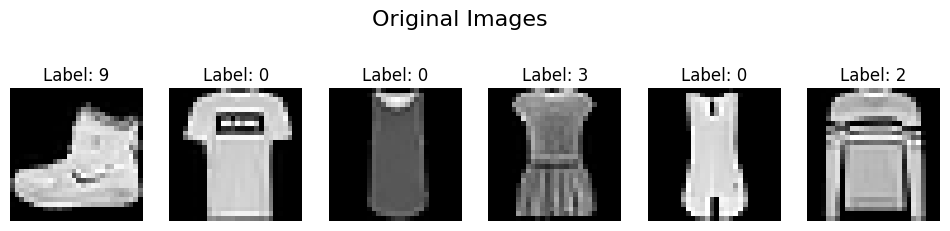

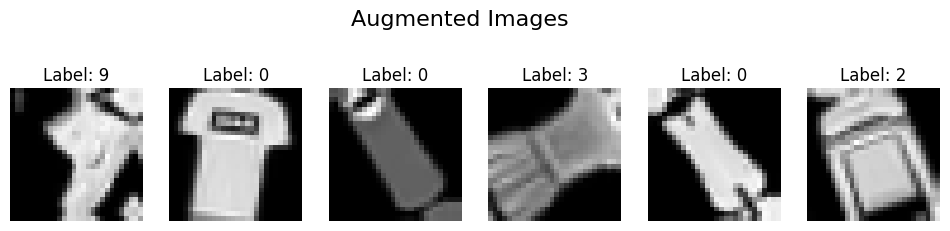

In [10]:
DATA_PATH = path

# Step 1: Load the Fashion MNIST Dataset from local
def load_fashion_mnist_data(path, kind='train'):
    """Load Fashion MNIST data from idx3-ubyte files."""
    if kind == 'train':
        labels_filename = 'train-labels-idx1-ubyte'
        images_filename = 'train-images-idx3-ubyte'
    else:
        labels_filename = 't10k-labels-idx1-ubyte'
        images_filename = 't10k-images-idx3-ubyte'

    labels_path = os.path.join(path, labels_filename)
    images_path = os.path.join(path, images_filename)

    with open(labels_path, 'rb') as lbpath:
        lbpath.seek(8)
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        imgpath.seek(16)
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 28, 28)

    return images, labels
try:
    # Load training data
    train_images, train_labels = load_fashion_mnist_data(DATA_PATH, kind='train')
    # Load test data
    test_images, test_labels = load_fashion_mnist_data(DATA_PATH, kind='t10k')
except FileNotFoundError as e:
    print(f"Error loading file: {e.filename}")
    print(f"Please make sure the data files are located in the '{DATA_PATH}' directory.")
    exit()

# Define class names for the labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Step 2: Adding some data augmentation to increase the training dataset
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=seed_value),
    tf.keras.layers.RandomRotation(0.2, seed=seed_value),
    tf.keras.layers.RandomZoom(0.2, seed=seed_value)
])

# Step 3: Preprocess the Data, normilize pixel data from 0~255 to 0~1.0
train_images = train_images / 255.0
test_images = test_images / 255.0

augmented_images = augmenter(train_images[..., None])  #  Keras data augmentation expects a channel dimension (1 because it's grayscale)
augmented_images = tf.squeeze(augmented_images).numpy()  # remove channel dimension


# Concatenate with original data
train_images_expanded = np.concatenate([train_images, augmented_images], axis=0)
train_labels_expanded = np.concatenate([train_labels, train_labels], axis=0)

def show_samples(images, labels, title, num=6):
    plt.figure(figsize=(12, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(num):
        plt.subplot(1, num, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.show()

# Original images
show_samples(train_images, train_labels, "Original Images")

# Augmented images
show_samples(augmented_images, train_labels, "Augmented Images")




**MODEL**

In [11]:
# Step 4: Build the Neural Network Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(124, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display a summary of the model's architecture
print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,078 (914.37 KB)

 Trainable params: 234,078 (914.37 KB)

 Non-trainable params: 0 (0.00 B)

**TRAINING**

In [12]:
# Step 6: Train the Model
print("\nStarting model training...")
history = model.fit(train_images_expanded, train_labels_expanded, epochs=15, validation_split=0.1)
print("Model training finished.")



Starting model training...
Epoch 1/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.7231 - loss: 0.7705 - val_accuracy: 0.7577 - val_loss: 0.6597
Epoch 2/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8211 - loss: 0.4828 - val_accuracy: 0.7838 - val_loss: 0.5871
Epoch 3/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8407 - loss: 0.4269 - val_accuracy: 0.8028 - val_loss: 0.5421
Epoch 4/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8526 - loss: 0.3897 - val_accuracy: 0.8029 - val_loss: 0.5323
Epoch 5/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8639 - loss: 0.3621 - val_accuracy: 0.8021 - val_loss: 0.5484
Epoch 6/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8702 - loss: 0.3451 - val_accuracy: 0.8083 - val_loss: 0.5275
Epoch 7/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8744 - loss: 0.3280 - val_accuracy: 0.8114 - val_loss: 0.5287
Epoch 8/15
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - acc

**PLOTTING HELPER FUNCS**

In [13]:
# Helper functions to visualize the predictions
def plot_image(i, predictions_array, true_label, img):
    true_label, img = true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"{class_names[predicted_label]} {100*np.max(predictions_array):2.0f}% ({class_names[true_label]})",
               color=color)

def plot_value_array(i, predictions_array, true_label):
    true_label = true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

**TESTING**


Evaluating model on test data...
313/313 - 2s - 5ms/step - accuracy: 0.8809 - loss: 0.4054

Test accuracy: 0.8809
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Visualizing a prediction...


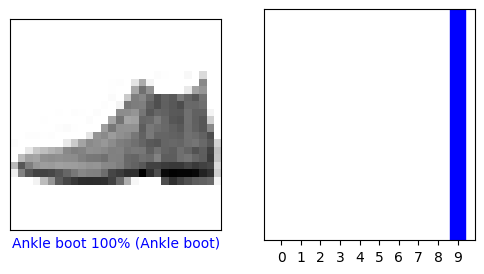


Plotting training history...


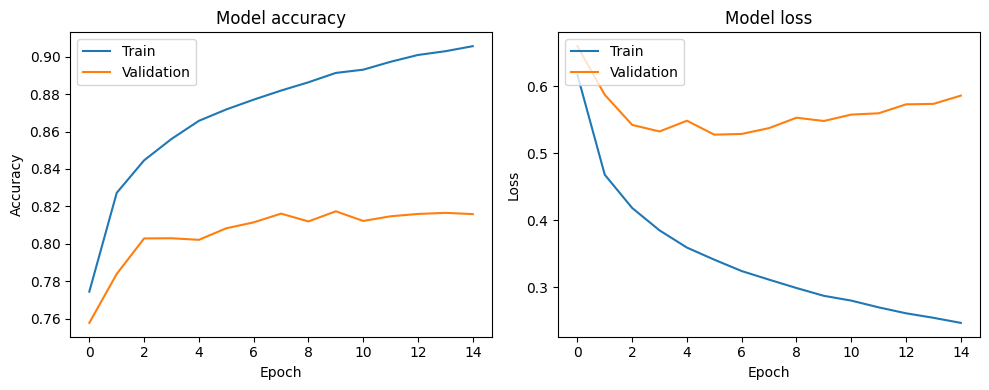

In [14]:
# Step 7: Evaluate the Model's Accuracy
print("\nEvaluating model on test data...")
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')

# Step 8: Make Predictions
predictions = model.predict(test_images)


# Let's visualize the prediction for the first image
print("\nVisualizing a prediction...")
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i], test_labels)
plt.show()

# Plot training & validation accuracy values
print("\nPlotting training history...")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()